# Model Selection: How to Choose the Right Model

In notebook 1 we prepared the Titanic data and trained our first model. That raises an obvious question: out of the many models that exist, which one should we actually use? Guessing is not a strategy. In this notebook we set up a fair, honest competition between six models, learn how to score them properly, and pick a winner we can defend with evidence.

**What you will learn**

- What a machine learning model really is, and meet six popular ones
- Why accuracy on the training data lies, and how cross-validation gives an honest score
- How to run a fair "tournament" between models with pipelines
- How to read a confusion matrix, and what precision, recall, F1 and AUC mean
- How to see overfitting and underfitting with your own eyes
- A practical checklist for choosing a model in real projects


## How to run this notebook

You can run this notebook in two ways:

- **Locally with Jupyter:** open it in Jupyter Notebook, JupyterLab or VS Code and run the cells top to bottom.
- **On Google Colab:** upload the file at [colab.research.google.com](https://colab.research.google.com) (File > Upload notebook) and run the cells top to bottom.

A few practical notes:

- The **setup cell** below installs any missing packages. On Colab most packages are already installed, so it usually does nothing.
- You do **not** need any account, API key or paid service. Only an internet connection to download the dataset.
- This notebook is **self-contained**: it repeats the data preparation from notebook 1 in one compact cell, so you can run it on its own. For the full explanation of each preparation step, see notebook 1.


In [1]:
# SETUP - run this cell first. It installs any missing packages.
# On Google Colab most packages are already installed, so this usually does nothing.
import importlib.util, subprocess, sys

def ensure(package, pip_name=None):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or package])

ensure("pandas"); ensure("numpy"); ensure("sklearn", "scikit-learn"); ensure("matplotlib"); ensure("seaborn")

## 1. The model zoo

Before we compare models, let's be clear about what a **model** actually is.

> A **model** is a function with adjustable knobs (called **parameters**). Training means turning those knobs automatically until the function's predictions match the examples in the training data as well as possible.

Quick recap from notebook 1: **classification** predicts a category (survived: yes or no), while **regression** predicts a number (for example, a house price). Predicting Titanic survival is classification, so all models today are classifiers.

**Meet today's contestants**

1. **Dummy classifier** - it ignores the passenger data completely and always predicts the most common answer ("died"). It sounds useless, and it is. That is exactly the point: it is our *floor*. Any model that cannot beat "always say died" has learned nothing.

2. **Logistic Regression** - a *weighted scorecard*. Each feature (age, sex, class, ...) gets a weight. The model adds up the weighted evidence and converts the total into a probability of survival. Simple, fast, and easy to explain: you can read the weights and see what pushed the prediction up or down.

3. **K-Nearest Neighbors (KNN)** - *ask your 5 most similar passengers*. To predict for a new passenger, KNN finds the 5 passengers in the training data that look most alike (similar age, fare, class, ...) and takes a vote among them. No real "training" happens; the data itself is the model.

4. **Decision Tree** - *a flowchart of yes/no questions*. "Is the passenger male? If yes, is the fare below 26?" and so on, until it reaches an answer. Very easy to read and explain, but a single deep tree happily memorizes the training data.

5. **Random Forest** - *hundreds of trees voting*. It builds many decision trees, each on a random sample of the rows and features, and lets them vote. Individual trees make different mistakes; the vote averages those mistakes away. Usually a strong, low-effort choice.

6. **Gradient Boosting** - *trees that learn from the previous tree's mistakes*. It builds small trees one after another, and each new tree focuses on the examples the previous trees got wrong. Often the most accurate of the classic models on tabular data, at the cost of being slower and harder to interpret.

**Cheat sheet**

| Model | Easy to interpret? | Needs scaled features? | Training speed | Typical strength |
|---|---|---|---|---|
| Dummy | Trivial | No | Instant | Honest baseline |
| Logistic Regression | High | Yes | Very fast | Simple, explainable |
| K-Nearest Neighbors | Medium | Yes (critical) | Fast (slow to predict) | Local patterns |
| Decision Tree | High | No | Fast | Readable rules |
| Random Forest | Low | No | Medium | Strong all-rounder |
| Gradient Boosting | Low | No | Medium/slow | Often top accuracy |

Note the "needs scaled features" column: KNN measures *distance* between passengers, so a feature with big numbers (Fare: 0-512) would drown out a feature with small numbers (SibSp: 0-8) unless we scale them. Our preprocessing pipeline scales the numeric features, so every model gets data it is happy with.


## 2. Data prep recap (from notebook 1)

We reuse exactly the same preparation we built step by step in notebook 1. Here it is compressed into one cell. If any line looks mysterious, notebook 1 explains it in full. In short, we:

- extract a **Title** (Mr/Mrs/Miss/Master/Rare) from each passenger's name,
- add **FamilySize** (siblings/spouses + parents/children + the passenger) and **IsAlone**,
- build a **preprocessor** that fills missing values, scales numeric columns and one-hot encodes categorical columns,
- split the data into a training set (80%) and a locked-away test set (20%).

The preprocessor is *not* applied yet - we will plug it into a pipeline together with each model. Section 5 explains why that matters.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

sns.set_theme(style="whitegrid")

# 1) Load the data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2) Feature engineering (same as notebook 1)
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
common_titles = ["Mr", "Mrs", "Miss", "Master"]
df.loc[~df["Title"].isin(common_titles), "Title"] = "Rare"
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# 3) Choose the columns the models will use
numeric_features = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
categorical_features = ["Pclass", "Sex", "Embarked", "Title"]

X = df[numeric_features + categorical_features]
y = df["Survived"]

# 4) Preprocessing: different treatment for numeric vs categorical columns
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# 5) Train/test split - the test set stays locked away until section 6
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows:    ", X_test.shape[0])

Training rows: 712
Test rows:     179


## 3. Why we need a fair referee

Imagine grading students on the exact questions they practiced at home. Everyone scores high, and the grade means nothing. Models have the same problem:

> **Overfitting** means a model has memorized the training examples (including their noise) instead of learning the general pattern. It looks brilliant on data it has seen and stumbles on data it has not.

So the score a model gets **on its own training data lies**. To judge honestly, we must always test on data the model has *never seen*.

**Idea 1: three piles of data.** Split into *train* (learn), *validation* (compare models), and *test* (final exam, touched once at the very end). This works, but with a small dataset like ours (891 passengers), a single validation pile is small and its score depends a lot on which rows happened to land in it. Bad luck can crown the wrong model.

**Idea 2: cross-validation.**

> **Cross-validation (CV)** splits the training data into K equal parts ("folds"), then trains K times. Each time, one fold plays test and the other K-1 folds play train. The final score is the average over the K rounds.

With K = 5 it looks like this (each row is one round):

```
Round 1:  [TEST ] [train] [train] [train] [train]  -> score 1
Round 2:  [train] [TEST ] [train] [train] [train]  -> score 2
Round 3:  [train] [train] [TEST ] [train] [train]  -> score 3
Round 4:  [train] [train] [train] [TEST ] [train]  -> score 4
Round 5:  [train] [train] [train] [train] [TEST ]  -> score 5

CV score = average of the 5 scores  (and their spread tells us how stable the model is)
```

Why this beats a single validation split:

- **Every row gets a turn at being test data**, so no score depends on one lucky (or unlucky) split.
- We get **5 scores instead of 1**, so we also see how much the model *wobbles* between folds. A model with a good average but a huge wobble is less trustworthy.
- We only "spend" our precious test set once, at the very end.

Important: cross-validation happens **inside the training set only**. The real test set stays locked away until section 6.


**Let's watch the lie happen.** We take a decision tree with no depth limit (so it can memorize freely), and compare its score on its own training data against its honest cross-validation score. Same model, same data - very different numbers.


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# A tree with no depth limit can grow until it memorizes almost every passenger
memorizer = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42)),
])

# Score on the SAME data it trained on (this is the lying score)
memorizer.fit(X_train, y_train)
train_score = memorizer.score(X_train, y_train)

# Honest score: 5-fold cross-validation on the training set
cv_scores = cross_val_score(memorizer, X_train, y_train, cv=5, n_jobs=-1)

print(f"Accuracy on its own training data: {train_score:.3f}")
print(f"Honest 5-fold CV accuracy:         {cv_scores.mean():.3f}")
print(f"Gap:                               {train_score - cv_scores.mean():.3f}")

Accuracy on its own training data: 0.985
Honest 5-fold CV accuracy:         0.751
Gap:                               0.233


## 4. Baseline first: the dummy classifier

Rule number one of model selection: **establish the floor before admiring the ceiling.**

About 62% of passengers in our data died. So a "model" that always predicts "died" is right about 62% of the time *without looking at the data at all*. That number is our floor:

> Any model that cannot clearly beat "always say died" is useless, no matter how fancy its name is.

`DummyClassifier(strategy="most_frequent")` is exactly that model. Let's measure the floor with the same referee (5-fold CV) that every other model will face.


In [4]:
from sklearn.dummy import DummyClassifier

# How common is each answer in the training data?
print("Class balance in y_train:")
print(y_train.value_counts(normalize=True).round(3))
print()

dummy = Pipeline([
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent")),
])
dummy_scores = cross_val_score(dummy, X_train, y_train, cv=5, n_jobs=-1)

print(f"Dummy CV accuracy: {dummy_scores.mean():.3f} (+/- {dummy_scores.std():.3f})")
print("This is the floor. Every real model must beat this.")

Class balance in y_train:
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64



Dummy CV accuracy: 0.617 (+/- 0.003)
This is the floor. Every real model must beat this.


## 5. The tournament

Time to let the six contestants compete. Two rules keep the tournament fair:

**Rule 1: every model gets the same referee.** Each model is scored with the same 5-fold cross-validation on the same training data. We record two scores per model:

- **accuracy** - the fraction of passengers predicted correctly, and
- **F1** - a score that balances precision and recall (fully explained in section 6). For now: F1 punishes a model that ignores the smaller class ("survived"), which plain accuracy does not.

**Rule 2: the preprocessor goes INSIDE the pipeline, inside the CV loop.** This one is subtle but crucial. If we scaled and imputed the *whole* training set first and cross-validated afterwards, then during each CV round the "test fold" would already have influenced the scaler's mean and the imputer's median. Information would leak from test to train - **data leakage**, the same trap from notebook 1 - and every score would be slightly, dishonestly optimistic. Wrapping `preprocessor + model` in one `Pipeline` means each CV round re-fits the preprocessing on that round's training folds only. The pipeline makes cheating impossible.

We use `cross_validate` (a sibling of `cross_val_score` that can track several metrics at once), and collect mean and standard deviation per model in one tidy table.


In [5]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import make_scorer, f1_score

models = {
    "Dummy (baseline)":    DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}

# zero_division=0: the Dummy never predicts "survived", which would trigger a
# warning when computing F1. We tell sklearn to just score it 0 in that case.
scoring = {"accuracy": "accuracy", "f1": make_scorer(f1_score, zero_division=0)}

rows = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    cv_res = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring, n_jobs=-1)
    rows.append({
        "model": name,
        "accuracy_mean": cv_res["test_accuracy"].mean(),
        "accuracy_std":  cv_res["test_accuracy"].std(),
        "f1_mean":       cv_res["test_f1"].mean(),
        "f1_std":        cv_res["test_f1"].std(),
    })

results = pd.DataFrame(rows).set_index("model").sort_values("accuracy_mean", ascending=False)
results.round(3)

,accuracy_mean,accuracy_std,f1_mean,f1_std
model,,,,
Logistic Regression,0.819,0.020,0.758,0.027
Gradient Boosting,0.816,0.030,0.744,0.049
K-Nearest Neighbors,0.806,0.026,0.734,0.041
Random Forest,0.797,0.054,0.728,0.074
Decision Tree,0.751,0.022,0.683,0.029
Dummy (baseline),0.617,0.003,0.000,0.000


A table is precise, but a chart makes the ranking obvious. We draw a **horizontal bar chart** of mean CV accuracy, with a small black line on each bar showing the standard deviation across the 5 folds (the "wobble").


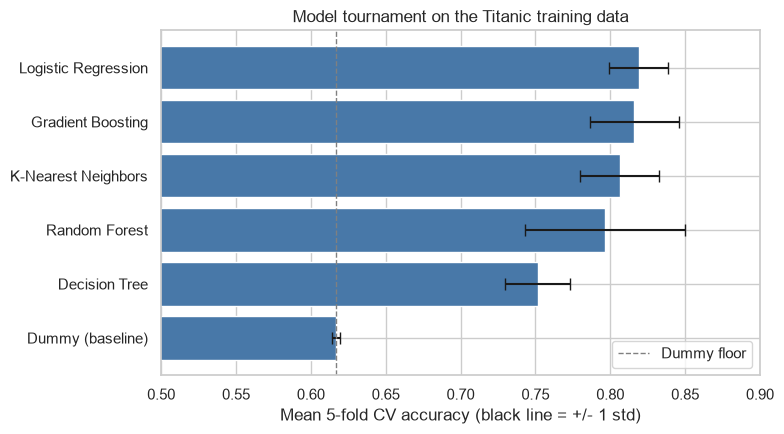

In [6]:
plot_df = results.sort_values("accuracy_mean")  # lowest at the bottom of the data -> top bar is the best

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_df.index, plot_df["accuracy_mean"],
        xerr=plot_df["accuracy_std"], color="#4878a8", capsize=4)
ax.set_xlabel("Mean 5-fold CV accuracy (black line = +/- 1 std)")
ax.set_title("Model tournament on the Titanic training data")
ax.set_xlim(0.5, 0.9)
ax.axvline(results.loc["Dummy (baseline)", "accuracy_mean"],
           color="gray", linestyle="--", linewidth=1, label="Dummy floor")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**How to read this result**

- Every real model clearly beats the dummy floor - good, they all learned *something*.
- The top models are close together. Differences of one or two percentage points, with error bars overlapping, are **not** strong evidence that one model is truly better.
- **Look at the std too.** A model that wobbles between folds (a long black line) is less trustworthy: its score depends on which passengers it happened to see. When two models have similar means, prefer the steadier one.
- Look who leads the table: the humble scorecard, Logistic Regression, with the tree ensembles breathing down its neck. Fancy does not automatically mean better.
- The single unlimited decision tree sits below the forest of trees - exactly the memorization problem we saw in section 3, now costing it the ranking.

So far we have judged everything with accuracy. Before we crown a champion, we need to ask a harder question: is accuracy even the right way to judge?


## 6. Beyond accuracy: metrics that tell the truth

**The 99% trap.** Imagine a disease that affects 1 person in 100. A "model" that always says "no disease" is 99% accurate - and completely worthless, because it misses every single sick patient. Accuracy misleads whenever one class is much more common than the other (**imbalanced data**). Our Titanic data is mildly imbalanced (62% died), so accuracy is usable here, but you should never trust it alone.

**The confusion matrix: the full story in four numbers.**

> A **confusion matrix** is a 2x2 table that counts every kind of hit and miss the model makes.

For Titanic survival ("positive" = survived):

| | Predicted: died | Predicted: survived |
|---|---|---|
| **Actually died** | True Negative (TN): predicted died, and they did | False Positive (FP): predicted survived, but they died |
| **Actually survived** | False Negative (FN): predicted died, but they survived | True Positive (TP): predicted survived, and they did |

From these four counts we build the metrics that matter:

- **Precision** = TP / (TP + FP). *"Of everyone we said survives, how many actually did?"* High precision = few false alarms.
- **Recall** = TP / (TP + FN). *"Of everyone who actually survived, how many did we catch?"* High recall = few missed cases.
- **F1** = the harmonic mean of precision and recall - their compromise. It is only high when *both* are decent; one bad value drags it down.

**Which metric matters when?** It depends on which mistake hurts more:

- **Spam filter:** a false positive (real email sent to spam) is painful; a false negative (one spam slips through) is mildly annoying. Optimize **precision**.
- **Cancer screening:** a false negative (missed cancer) can be fatal; a false positive means one extra test. Optimize **recall**.
- No strong preference? **F1** balances the two.

Time to apply this. We crown the tournament winner as our **champion**, train it on the full training set, and evaluate it - for the first time in this notebook - on the locked-away **test set**. This is the final exam: 179 passengers the model has never seen in any form.


Champion: Logistic Regression
Test accuracy: 0.838


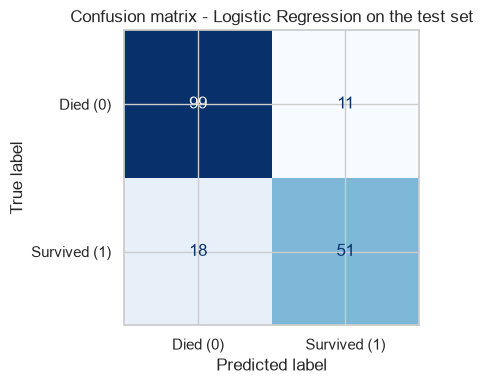

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Pick the tournament winner automatically (best mean CV accuracy, dummy excluded)
champion_name = results.drop(index="Dummy (baseline)")["accuracy_mean"].idxmax()
print("Champion:", champion_name)

champion_pipe = Pipeline([("prep", preprocessor), ("model", models[champion_name])])
champion_pipe.fit(X_train, y_train)          # train on ALL training rows
y_pred = champion_pipe.predict(X_test)       # predict the unseen test set

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died (0)", "Survived (1)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion matrix - {champion_name} on the test set")
plt.tight_layout()
plt.show()

**Reading the matrix, cell by cell** (rows = truth, columns = prediction):

- Top-left (TN): passengers who died and the model said died. Correct.
- Top-right (FP): passengers who died but the model said survived. False alarms.
- Bottom-left (FN): passengers who survived but the model said died. Missed survivors.
- Bottom-right (TP): passengers who survived and the model said survived. Correct.

Notice the model makes both kinds of mistakes, and not necessarily in equal numbers. `classification_report` turns these counts into precision, recall and F1 for each class in one go.


In [8]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print(classification_report(y_test, y_pred, target_names=["Died (0)", "Survived (1)"]))

print(f"Precision (survived): {precision_score(y_test, y_pred):.3f}  <- of predicted survivors, fraction correct")
print(f"Recall    (survived): {recall_score(y_test, y_pred):.3f}  <- of true survivors, fraction caught")
print(f"F1        (survived): {f1_score(y_test, y_pred):.3f}  <- compromise of the two")

              precision    recall  f1-score   support

    Died (0)       0.85      0.90      0.87       110
Survived (1)       0.82      0.74      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179

Precision (survived): 0.823  <- of predicted survivors, fraction correct
Recall    (survived): 0.739  <- of true survivors, fraction caught
F1        (survived): 0.779  <- compromise of the two


### 6.1 Optional depth: the ROC curve and AUC

This subsection is a bonus - skip it on a first read if you like.

Most classifiers do not just output "survived / died"; internally they produce a **probability** (for example, "73% chance of survival") and apply a cutoff (usually 50%) to make the final call. Moving that cutoff trades false alarms against missed survivors.

> The **ROC curve** shows every possible trade-off: for each cutoff, it plots the true positive rate (recall) against the false positive rate. The **AUC** (Area Under the Curve) squeezes the whole curve into one number: the probability that the model ranks a random survivor above a random non-survivor.

Rules of thumb: AUC 0.5 = coin flip (the dashed diagonal), 1.0 = perfect ranking, 0.8+ = solid. AUC is a great single number for *"how well does this model rank passengers?"*, independent of any particular cutoff.


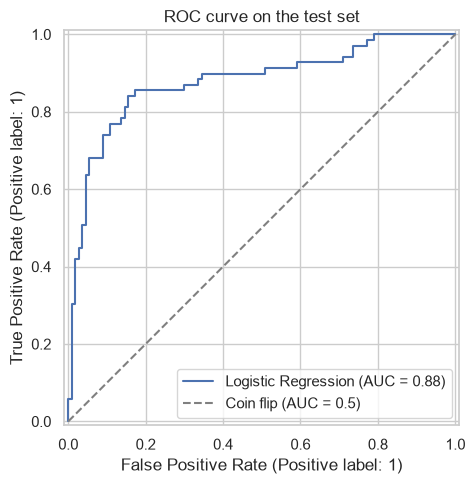

AUC: 0.878


In [9]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(champion_pipe, X_test, y_test, ax=ax, name=champion_name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Coin flip (AUC = 0.5)")
ax.set_title("ROC curve on the test set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

auc = roc_auc_score(y_test, champion_pipe.predict_proba(X_test)[:, 1])
print(f"AUC: {auc:.3f}")

## 7. Overfitting vs underfitting, with your own eyes

We keep using the words *overfitting* and *memorizing*. Let's actually **see** them. A decision tree has one knob that controls how much it can memorize: `max_depth`, the maximum number of yes/no questions on any path.

- Depth 1: the tree may ask only ONE question ("male or female?"). Far too simple.
- Depth 20: the tree can carve out a private little box for nearly every passenger. Far too flexible.

We sweep `max_depth` from 1 to 20 and, for each depth, record two numbers: accuracy on the training data itself, and honest 5-fold CV accuracy. Watching the two curves separate is the single most instructive plot in machine learning.


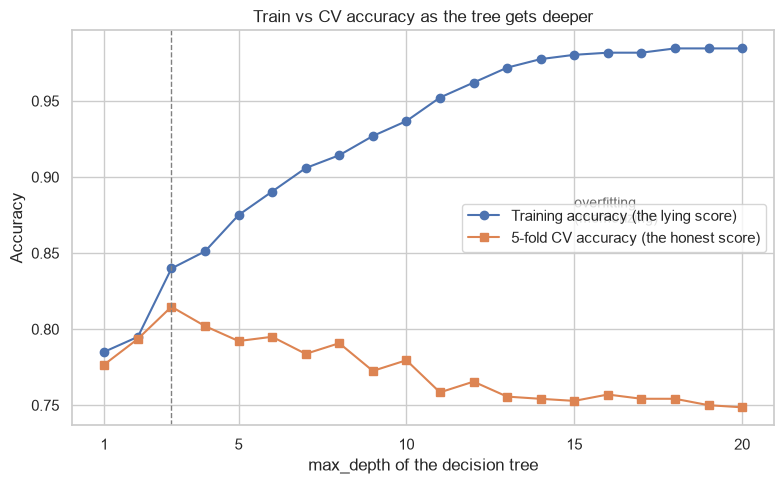

Best CV accuracy 0.815 at depth 3
At depth 20: train 0.985 vs CV 0.749 -> gap 0.236


In [10]:
depths = range(1, 21)
train_acc, cv_acc = [], []

for d in depths:
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=d, random_state=42)),
    ])
    pipe.fit(X_train, y_train)
    train_acc.append(pipe.score(X_train, y_train))
    cv_acc.append(cross_val_score(pipe, X_train, y_train, cv=5, n_jobs=-1).mean())

best_depth = list(depths)[int(np.argmax(cv_acc))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, train_acc, marker="o", label="Training accuracy (the lying score)")
ax.plot(depths, cv_acc, marker="s", label="5-fold CV accuracy (the honest score)")
ax.axvline(best_depth, color="gray", linestyle="--", linewidth=1)
ax.annotate("underfitting\n(too simple)", xy=(1.4, 0.66), fontsize=10, color="dimgray")
ax.annotate("overfitting\n(memorizing)", xy=(15, 0.87), fontsize=10, color="dimgray")
ax.annotate(f"sweet spot\n(depth {best_depth})", xy=(best_depth + 0.3, 0.70), fontsize=10, color="dimgray")
ax.set_xlabel("max_depth of the decision tree")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs CV accuracy as the tree gets deeper")
ax.set_xticks([1, 5, 10, 15, 20])
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

print(f"Best CV accuracy {max(cv_acc):.3f} at depth {best_depth}")
print(f"At depth 20: train {train_acc[-1]:.3f} vs CV {cv_acc[-1]:.3f} -> gap {train_acc[-1] - cv_acc[-1]:.3f}")

**What the plot tells us**

- **Left side (shallow trees):** both curves are low. The model is too simple to capture the pattern - **underfitting**.
- **Right side (deep trees):** training accuracy keeps climbing toward 1.0 while CV accuracy stalls or drops. The growing **gap between the curves is memorizing, not learning** - **overfitting**.
- The sweet spot is in the middle, where CV accuracy peaks.

Two words you will hear constantly, each in one sentence:

- **Bias** is error from being too simple to capture the real pattern - the left side of the plot, where both curves are low.
- **Variance** is error from being so flexible that the model changes with every quirk of the training sample - the right side, where the curves fly apart.

Every model choice is a negotiation between the two. That is why the middle of the plot wins.


## 8. The learning curve: would more data help?

A different practical question: if we somehow collected more passengers, would our champion get better? Or is it already squeezing everything out of the pattern?

> A **learning curve** trains the model on growing slices of the training data (10%, 32%, ..., 100%) and plots the training score and CV score at each size.

How to read it:

- CV curve **still rising** at the right edge: more data would likely help.
- CV curve **flat** and close to the training curve: more data will not fix much; better features or a different model might.
- **Big gap** between the curves: the model is overfitting; more data (or a simpler model) usually shrinks the gap.

sklearn's `learning_curve` does all the training rounds for us; we just plot.


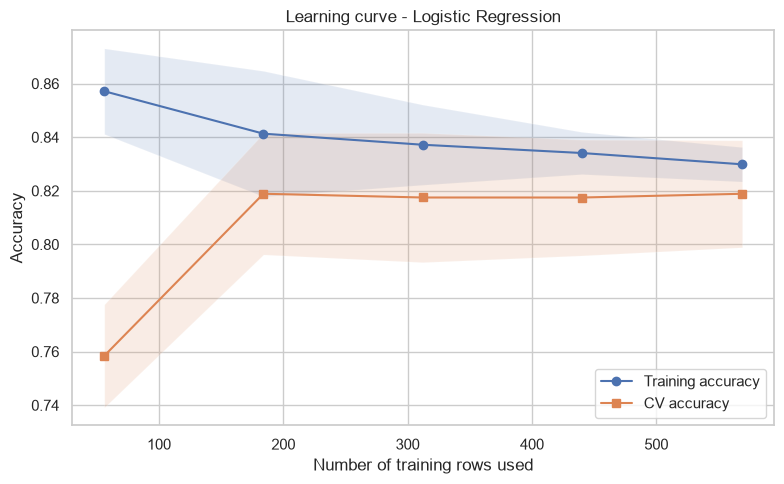

CV accuracy with 56 rows: 0.758
CV accuracy with 569 rows: 0.819


In [11]:
from sklearn.model_selection import learning_curve

train_sizes, lc_train, lc_cv = learning_curve(
    champion_pipe, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 5), cv=5, n_jobs=-1,
    shuffle=True, random_state=42,
)

tr_mean, tr_std = lc_train.mean(axis=1), lc_train.std(axis=1)
cv_mean, cv_std = lc_cv.mean(axis=1), lc_cv.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, tr_mean, marker="o", label="Training accuracy")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15)
ax.plot(train_sizes, cv_mean, marker="s", label="CV accuracy")
ax.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.15)
ax.set_xlabel("Number of training rows used")
ax.set_ylabel("Accuracy")
ax.set_title(f"Learning curve - {champion_name}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"CV accuracy with {train_sizes[0]} rows: {cv_mean[0]:.3f}")
print(f"CV accuracy with {train_sizes[-1]} rows: {cv_mean[-1]:.3f}")

**In plain words:** the CV curve climbs steeply at first - the model is data-hungry when it has only a few dozen passengers - and then flattens out. By the right edge it has mostly leveled off, so doubling the dataset would probably buy only a small improvement. Also notice the two curves end close together: our champion is not badly overfitting. To improve further we need better features or better model settings, not more rows - and tuning settings is exactly what notebook 3 is about.


## 9. How to choose in real life: a checklist

Everything in this notebook compresses into six questions. Run through them every time you pick a model:

1. **Did it beat the baseline?** If not, stop. Nothing else matters.
2. **Does the metric match the problem?** Accuracy for balanced data with equal mistake costs; precision when false alarms hurt; recall when misses hurt; F1 as the compromise; AUC to compare ranking quality.
3. **Simple model first.** If Logistic Regression is within a hair of Random Forest, ship the simple one: it is faster, easier to explain to your boss (and to a regulator), and harder to break.
4. **Check the std across folds.** Between two models with similar means, prefer the one that wobbles less.
5. **Count the practical costs.** Prediction speed, memory, retraining time. A model that needs a minute per prediction cannot power a live website.
6. **Will a human need to understand the decision?** Loan rejections and medical decisions often legally require an explanation. A scorecard or a small tree can give one; a 200-tree ensemble struggles.

The one-line summary: **the best model is the simplest one that beats the baseline on the metric that matches your problem, reliably across folds.**


## 10. Save the decision

Let's put our final verdict on the record: the champion's name and its scores on the untouched test set. We also save the tournament table to an `outputs/` folder next to this notebook, so we can refer back to it later.

**Handoff to notebook 3.** In our run the humble scorecard, Logistic Regression, takes the crown by a whisker, with the tree ensembles well within one standard deviation behind it. That is a very common real-world outcome, and by our checklist the simple scorecard is the model we would ship today.

There is a catch, though: Logistic Regression has almost no knobs left to tune, while the Random Forest has many - and we ran it with default-ish settings. So in notebook 3 we squeeze more performance out of this leaderboard: we take the **Random Forest**, the contestant with the most room to improve, tune its knobs systematically, and put the result online behind a small web app.


In [12]:
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)
results.round(4).to_csv("outputs/model_selection_results.csv")

print("=" * 52)
print("FINAL DECISION")
print("=" * 52)
print(f"Champion model:   {champion_name}")
print(f"Test accuracy:    {accuracy_score(y_test, y_pred):.3f}")
print(f"Test precision:   {precision_score(y_test, y_pred):.3f}")
print(f"Test recall:      {recall_score(y_test, y_pred):.3f}")
print(f"Test F1:          {f1_score(y_test, y_pred):.3f}")
print(f"Test AUC:         {auc:.3f}")
print("=" * 52)
print("Tournament table saved to outputs/model_selection_results.csv")

FINAL DECISION
Champion model:   Logistic Regression
Test accuracy:    0.838
Test precision:   0.823
Test recall:      0.739
Test F1:          0.779
Test AUC:         0.878
Tournament table saved to outputs/model_selection_results.csv


## 11. Key takeaways

- A **model is a function with learnable knobs**; different models make different assumptions about the pattern in the data.
- **Training accuracy lies.** Always judge models on data they have not seen.
- **Cross-validation** is the fair referee: every row gets a turn at being test data, and the spread across folds tells you how stable a score is.
- **Baseline first.** A model that cannot beat "always predict the majority" has learned nothing.
- Put preprocessing **inside the pipeline** so cross-validation cannot leak information from the test folds.
- **Accuracy alone can mislead**, especially on imbalanced data. The confusion matrix, precision, recall, F1 and AUC each answer a different question - pick the one that matches the cost of your mistakes.
- **Overfitting** = memorizing (big train-vs-CV gap, high variance). **Underfitting** = too simple (both scores low, high bias). The sweet spot is in between.
- A **learning curve** tells you whether collecting more data is worth the effort.
- In real life: **the simplest model that reliably beats the baseline on the right metric wins.**


## 12. Practice exercises

Try these yourself before peeking at the solutions.

**Exercise 1 - A new contestant.** Add `ExtraTreesClassifier` (from `sklearn.ensemble`, use `n_estimators=200, random_state=42, n_jobs=-1`) to the tournament. It is a cousin of Random Forest that adds even more randomness to how trees are built. Score it with the same 5-fold CV and both metrics. Where does it land in the ranking?

**Exercise 2 - Change the referee's rulebook.** Re-rank the tournament by **F1** instead of accuracy. Does the ranking change? Which model moves the most, and can you explain why the Dummy's F1 is exactly 0?

**Exercise 3 - Metrics by hand.** Using only the four numbers in the champion's confusion matrix from section 6 (TN, FP, FN, TP), compute accuracy, precision and recall with plain arithmetic - no sklearn metric functions. Then check your answers against sklearn.

**Exercise 4 - Choose the metric (no code).** A hospital uses a model to flag patients who may have a dangerous infection. A marketing team uses a model to select customers for an expensive gift box. Which metric should each team care about most, and why?


## 13. Solutions

**Solution 1 - A new contestant.** Same recipe as the tournament: wrap the new model in a pipeline with the shared preprocessor, score with the same referee, and slot the row into the table. Extra Trees usually lands very close to Random Forest - they are close cousins.


In [13]:
from sklearn.ensemble import ExtraTreesClassifier

et_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])
et_res = cross_validate(et_pipe, X_train, y_train, cv=5, scoring=scoring, n_jobs=-1)

et_row = pd.DataFrame([{
    "accuracy_mean": et_res["test_accuracy"].mean(),
    "accuracy_std":  et_res["test_accuracy"].std(),
    "f1_mean":       et_res["test_f1"].mean(),
    "f1_std":        et_res["test_f1"].std(),
}], index=pd.Index(["Extra Trees"], name="model"))

results_ex1 = pd.concat([results, et_row]).sort_values("accuracy_mean", ascending=False)
results_ex1.round(3)

,accuracy_mean,accuracy_std,f1_mean,f1_std
model,,,,
Logistic Regression,0.819,0.020,0.758,0.027
Gradient Boosting,0.816,0.030,0.744,0.049
K-Nearest Neighbors,0.806,0.026,0.734,0.041
Random Forest,0.797,0.054,0.728,0.074
Extra Trees,0.775,0.058,0.705,0.075
Decision Tree,0.751,0.022,0.683,0.029
Dummy (baseline),0.617,0.003,0.000,0.000


**Solution 2 - Change the referee's rulebook.** Handy shortcut: `cross_validate` already recorded F1 for every model during the tournament, so there is nothing to re-run - we just sort the same table by a different column and compare the two rankings side by side.


In [14]:
rank_acc = results_ex1.sort_values("accuracy_mean", ascending=False)
rank_f1 = results_ex1.sort_values("f1_mean", ascending=False)

comparison = pd.DataFrame({
    "rank by accuracy": rank_acc.index,
    "rank by F1": rank_f1.index,
})
comparison.index = comparison.index + 1  # ranks start at 1, not 0
print(comparison.to_string())

print()
print("Dummy F1:", round(results_ex1.loc["Dummy (baseline)", "f1_mean"], 3))

      rank by accuracy           rank by F1
1  Logistic Regression  Logistic Regression
2    Gradient Boosting    Gradient Boosting
3  K-Nearest Neighbors  K-Nearest Neighbors
4        Random Forest        Random Forest
5          Extra Trees          Extra Trees
6        Decision Tree        Decision Tree
7     Dummy (baseline)     Dummy (baseline)

Dummy F1: 0.0


The top of the ranking usually stays similar, but positions can shuffle: F1 only looks at how well a model handles the "survived" class, so models that are cautious about predicting survival (catching fewer survivors) slip down. The **Dummy's F1 is exactly 0** because it never predicts "survived": it has zero true positives, so both its precision and its recall for that class are 0. That is F1 doing its job - accuracy gave the Dummy a flattering 62%, F1 calls it worthless.


**Solution 3 - Metrics by hand.** `cm.ravel()` flattens the 2x2 matrix into the four counts in the order TN, FP, FN, TP. Then it is plain arithmetic.


In [15]:
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

accuracy_hand = (tp + tn) / (tp + tn + fp + fn)   # all correct / all passengers
precision_hand = tp / (tp + fp)                    # of predicted survivors, correct ones
recall_hand = tp / (tp + fn)                       # of true survivors, ones we caught

print(f"Accuracy  by hand: {accuracy_hand:.3f}   sklearn: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision by hand: {precision_hand:.3f}   sklearn: {precision_score(y_test, y_pred):.3f}")
print(f"Recall    by hand: {recall_hand:.3f}   sklearn: {recall_score(y_test, y_pred):.3f}")

TN=99  FP=11  FN=18  TP=51
Accuracy  by hand: 0.838   sklearn: 0.838
Precision by hand: 0.823   sklearn: 0.823
Recall    by hand: 0.739   sklearn: 0.739


**Solution 4 - Choose the metric.**

- **The hospital should optimize recall.** A false negative means a patient with a dangerous infection is sent home untreated - potentially fatal. A false positive means one unnecessary extra test - cheap by comparison. The hospital wants to *catch every true case*, even at the cost of extra false alarms.
- **The marketing team should optimize precision.** Every gift box costs real money, so a false positive (an expensive box sent to someone who will never buy) burns budget. A false negative (a good customer overlooked) is a missed opportunity, but costs nothing directly. The team wants *the customers it picks to be the right ones*.

Same mathematics, opposite priorities - which is exactly why "which metric?" must be answered by the business problem, never by the algorithm.

---

*Next up: notebook 3, where we take the Random Forest - the contestant with the most tunable knobs - squeeze more performance out of it with a systematic search, and deploy it as a small web app anyone can use.*
